# Proyecto Sprint 6 - Tienda online de videojuegos -> Análisis

## Paso 1. Abre el archivo de datos y estudia la información general

### Importación de librerías

In [ ]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar datos

In [ ]:
df_games=pd.read_csv('games.csv')

### Inspeccionar datos

In [ ]:
df_games.info()
print(df_games.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
                        Name Platform  Year_of_Release         Genre  \
0                 Wii Sports      Wii           2006.0        Sports   
1          Super Mario Bros.      NES           1985.0      Platform   
2             Mario Kart 

### Observaciones de los datos
El dataframe obtenido contiene 11 columnas y 16715 filas con diferentes tipos de datos, las columnas y las primeras observaciones son:
 0   Name             16713 non-null  object -> Tipo de datos correcto, hay datos ausentes que hay que evaluar
 1   Platform         16715 non-null  object -> Tipo de datos correcto, no hay datos ausentes
 2   Year_of_Release  16446 non-null  float64 -> El tipo de dato puede cambiarse a int64, hay datos ausentes por evaluar
 3   Genre            16713 non-null  object -> Tipo de datos correcto, hay datos ausentes que hay que evaluar
 4   NA_sales         16715 non-null  float64 -> Tipo de datos correcto, no hay datos ausentes
 5   EU_sales         16715 non-null  float64 -> Tipo de datos correcto, no hay datos ausentes
 6   JP_sales         16715 non-null  float64 -> Tipo de datos correcto, no hay datos ausentes
 7   Other_sales      16715 non-null  float64 -> Tipo de datos correcto, no hay datos ausentes
 8   Critic_Score     8137 non-null   float64 -> Tipo de datos correcto, hay datos ausentes que evaluar
 9   User_Score       10014 non-null  object -> Debido a que hay valores 'tbd' (de acuerdo con la descripción del proyecto) es necesario evaluar que hacer con ellos
 10  Rating           9949 non-null   object -> Tipo de datos correcto, hay datos ausentes por evaluar

## Paso 2. Prepara los datos

### Reemplazo los nombres de las columnas por minúsculas

In [ ]:
df_games.columns=df_games.columns.str.lower()
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### Calculo el total de ventas

In [ ]:
df_games['total_sales']=df_games['na_sales']+df_games['eu_sales']+df_games['jp_sales']+df_games['other_sales']

Verifico si hay juegos con ventas totales en 0

In [ ]:
print(df_games[df_games['total_sales']==0])

                                                   name platform  \
16676                                  G1 Jockey 4 2008      PS3   
16709  SCORE International Baja 1000: The Official Game      PS2   

       year_of_release   genre  na_sales  eu_sales  jp_sales  other_sales  \
16676           2008.0  Sports       0.0       0.0       0.0          0.0   
16709           2008.0  Racing       0.0       0.0       0.0          0.0   

       critic_score user_score rating  total_sales  
16676           NaN        NaN    NaN          0.0  
16709           NaN        NaN    NaN          0.0  


Como la cantidad de datos obtenida es muy pequeña comparada con el total de datos no tomaré acciones específicas para estos juegos.

### Vemos los ausentes de cada columna para analizarlos y posteriormente cambiamos el tipo de dato de las columnas

Evaluo ausentes, datos extraños y tipo de datos a continuación

#### Name y Genre

In [ ]:
print(df_games[df_games['name'].isna()])
ausentes=df_games['name'].isna().sum()
print(f'Valores NaN: {ausentes}')

      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score user_score rating  total_sales  
659           0.08           NaN        NaN    NaN         2.39  
14244         0.00           NaN        NaN    NaN         0.03  
Valores NaN: 2


No revisé lo ausentes de 'genre' porque al ver los de 'name' vi que coinciden. Las 2 filas con datos NaN son del año 1993. Renombraré ambos juegos como 'Uknown_1' y 'Unknown_2' y comprobaré que no estén duplicados. En el df de juegos de 2016 no hay datos ausentes en estas columnas.

In [ ]:
df_games.loc[659, 'name']='Unknown_1'
df_games.loc[14244, 'name']='Unknown_2'
ausentes=df_games['name'].isna().sum()
print(f'Valores NaN: {ausentes}')
print(df_games[df_games['name']=='Unknown_1'])
print(df_games[df_games['name']=='Unknown_2'])

df_games.loc[659, 'genre']='Unknown'
df_games.loc[14244, 'genre']='Unknown'
ausentes=df_games['genre'].isna().sum()
print(f'Valores NaN: {ausentes}')
print(df_games[df_games['genre']=='Unknown'])

Valores NaN: 0
          name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659  Unknown_1      GEN           1993.0   NaN      1.78      0.53       0.0   

     other_sales  critic_score user_score rating  total_sales  
659         0.08           NaN        NaN    NaN         2.39  
            name platform  year_of_release genre  na_sales  eu_sales  \
14244  Unknown_2      GEN           1993.0   NaN       0.0       0.0   

       jp_sales  other_sales  critic_score user_score rating  total_sales  
14244      0.03          0.0           NaN        NaN    NaN         0.03  
Valores NaN: 0
            name platform  year_of_release    genre  na_sales  eu_sales  \
659    Unknown_1      GEN           1993.0  Unknown      1.78      0.53   
14244  Unknown_2      GEN           1993.0  Unknown      0.00      0.00   

       jp_sales  other_sales  critic_score user_score rating  total_sales  
659        0.00         0.08           NaN        NaN    NaN         2.39  
14244 

#### Year_of_release

In [ ]:
print(df_games[df_games['year_of_release'].isna()].head(10))
ausentes=df_games['year_of_release'].isna().sum()
print(f'Valores NaN: {ausentes}')

                                            name platform  year_of_release  \
183                              Madden NFL 2004      PS2              NaN   
377                             FIFA Soccer 2004      PS2              NaN   
456                   LEGO Batman: The Videogame      Wii              NaN   
475                   wwe Smackdown vs. Raw 2006      PS2              NaN   
609                               Space Invaders     2600              NaN   
627                                    Rock Band     X360              NaN   
657     Frogger's Adventures: Temple of the Frog      GBA              NaN   
678  LEGO Indiana Jones: The Original Adventures      Wii              NaN   
719                               Call of Duty 3      Wii              NaN   
805                                    Rock Band      Wii              NaN   

         genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
183     Sports      4.26      0.26      0.01         0.71         

Veo que algunos de los juegos incluyen un año en su nombre, no considero prudente usar ese dato como año de lanzamiento ya que hay casos, como en los autos, que el modelo 2005 en realidad salió al mercado en 2004. Intentaré revisar duplicados para ver si encuentro algún patrón

In [ ]:
print(df_games[df_games.duplicated()])

Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales, eu_sales, jp_sales, other_sales, critic_score, user_score, rating, total_sales]
Index: []


Revisare en que consolas tengo datos ausentes

In [ ]:
consolas=df_games[df_games['year_of_release'].isna()]['platform']
print(consolas.unique())

['PS2' 'Wii' '2600' 'X360' 'GBA' 'PC' 'PS3' 'PS' 'PSP' 'XB' 'GB' 'DS' 'GC'
 '3DS' 'N64' 'PSV']


Calculemos los promedios de año de lanzamiento de los juegos por consola

In [ ]:
lanzamiento=df_games.groupby('platform')['year_of_release'].mean().round(0).astype('int64')
#lanzamiento=lanzamiento.rename(columns={'year_of_release': 'average_year'})
lanzamiento=lanzamiento.to_dict()
print(lanzamiento)

{'2600': 1982, '3DO': 1995, '3DS': 2013, 'DC': 2000, 'DS': 2008, 'GB': 1996, 'GBA': 2003, 'GC': 2003, 'GEN': 1993, 'GG': 1992, 'N64': 1999, 'NES': 1987, 'NG': 1994, 'PC': 2009, 'PCFX': 1996, 'PS': 1998, 'PS2': 2005, 'PS3': 2011, 'PS4': 2015, 'PSP': 2009, 'PSV': 2014, 'SAT': 1996, 'SCD': 1994, 'SNES': 1994, 'TG16': 1995, 'WS': 2000, 'Wii': 2009, 'WiiU': 2014, 'X360': 2010, 'XB': 2004, 'XOne': 2015}


Sustituyamos los valores NaN por estos promedios y convirtamos la columna a datos enteros

In [ ]:
df_games['year_of_release']=df_games['year_of_release'].fillna(df_games['platform'].map(lanzamiento)).astype('int64')
ausentes=df_games['year_of_release'].isna().sum()
print(f'Valores NaN: {ausentes}')

Valores NaN: 0


#### Critic_score

In [ ]:
print(df_games[df_games['critic_score'].isna()])
ausentes=df_games['critic_score'].isna().sum()
print(f'Valores NaN: {ausentes}')

                                name platform  year_of_release         genre  \
1                  Super Mario Bros.      NES             1985      Platform   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                             Tetris       GB             1989        Puzzle   
9                          Duck Hunt      NES             1984       Shooter   
10                        Nintendogs       DS             2005    Simulation   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

El único patrón que veo es que, al menos en los datos que veo, coincide que las 2 columnas de calificación y la de rating contienen NaN, se que no es en el 100% de los casos porque la cantidad de ausentes en cada columna es diferente. Critic_score es la columna de estas 3 que tiene más ausentes, seguido de rating y al final user_score. Antes de sustituir valores ausentes analizaré si hay alguna correlación entre estos

In [ ]:
ausentes=df_games[df_games['critic_score'].isna() & df_games['user_score'].isna() & df_games['rating'].isna()]
print(ausentes)

                                name platform  year_of_release         genre  \
1                  Super Mario Bros.      NES             1985      Platform   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                             Tetris       GB             1989        Puzzle   
9                          Duck Hunt      NES             1984       Shooter   
10                        Nintendogs       DS             2005    Simulation   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

No encontré algún dato relevante. Para esta columna en particular, dejaré los datos NaN así, si los cambio por la media o por algún otro valor se ve a generar una diferencia en la varianza de los datos.

#### User_score

In [ ]:
print(df_games[df_games['user_score'].isna()].head(10))
ausentes=df_games['user_score'].isna().sum()
print(f'Valores NaN: {ausentes}')

                             name platform  year_of_release         genre  \
1               Super Mario Bros.      NES             1985      Platform   
4        Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                          Tetris       GB             1989        Puzzle   
9                       Duck Hunt      NES             1984       Shooter   
10                     Nintendogs       DS             2005    Simulation   
12    Pokemon Gold/Pokemon Silver       GB             1999  Role-Playing   
18              Super Mario World     SNES             1990      Platform   
20  Pokemon Diamond/Pokemon Pearl       DS             2006  Role-Playing   
21               Super Mario Land       GB             1989      Platform   
22            Super Mario Bros. 3      NES             1988      Platform   

    na_sales  eu_sales  jp_sales  other_sales  critic_score user_score rating  \
1      29.08      3.58      6.81         0.77           NaN        NaN 

Esta columna es de tipo 'object' debido a que existen datos tbd. Veamos estos datos para analizar que hacer con ellos

In [ ]:
print(df_games[df_games['user_score']=='tbd'].head(10))

                                          name platform  year_of_release  \
119                              Zumba Fitness      Wii             2010   
301             Namco Museum: 50th Anniversary      PS2             2005   
520                            Zumba Fitness 2      Wii             2011   
645                               uDraw Studio      Wii             2010   
657   Frogger's Adventures: Temple of the Frog      GBA             2003   
718                            Just Dance Kids      Wii             2010   
726                  Dance Dance Revolution X2      PS2             2009   
821                            The Incredibles      GBA             2004   
881              Who wants to be a millionaire       PC             1999   
1047                             Tetris Worlds      GBA             2001   

           genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
119       Sports      3.45      2.59      0.00         0.66           NaN   
301      

Noto que para los juegos con user_score como 'tbd' las ventas en Japón son bajas, voy a evaluar ventas máximas y mínimas en Japón para estos datos y así determinaré si pudiera haber alguna relación (quizás los usuarios no evaluan juegos que no llegan a cierto umbral de ventas), lo mismo para ventas totales.

In [ ]:
maximo=df_games[df_games['user_score']=='tbd']['jp_sales'].max()
print(f'Valor máximo con calificación tbd de ventas en Japón: {maximo}')
minimo=df_games[~(df_games['user_score']=='tbd')]['jp_sales'].min()
print(f'Valor máximo con calificación numérica de ventas en Japón: {minimo}')

maximo=df_games[df_games['user_score']=='tbd']['total_sales'].max()
print(f'Valor máximo con calificación tbd de ventas totales: {maximo}')
minimo=df_games[~(df_games['user_score']=='tbd')]['total_sales'].min()
print(f'Valor máximo con calificación numérica de ventas totales: {minimo}')

Valor máximo con calificación tbd de ventas en Japón: 0.86
Valor máximo con calificación numérica de ventas en Japón: 0.0
Valor máximo con calificación tbd de ventas totales: 6.7
Valor máximo con calificación numérica de ventas totales: 0.0


Mi hipótesis falló. Mi siguiente hipótesis es que los juegos anteriores a cierto año no tienen calificación de usuarios.

In [ ]:
minimo=df_games[~(df_games['user_score']=='tbd')]['year_of_release'].min()
print(f'Primer año en el que se cuenta con registros de user_score: {minimo}')

Primer año en el que se cuenta con registros de user_score: 1980


Como no encontré ninguna coincidencia o información que me ayude a gestionar esos datos, procedo a converti la columna a númerica

In [ ]:
df_games['user_score']=pd.to_numeric(df_games['user_score'], errors='coerce')
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
 11  total_sales      16715 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.5+ MB


Para esta columna en particular, dejaré los datos NaN así, si los cambio por la media o por algún otro valor se va a generar una diferencia en la varianza de los datos. Voy a multiplicar por 10 el valor de la columna para estar en la misma escala que critic_score

In [ ]:
df_games['user_score']=df_games['user_score']*10
print(df_games['user_score'])

0        80.0
1         NaN
2        83.0
3        80.0
4         NaN
         ... 
16710     NaN
16711     NaN
16712     NaN
16713     NaN
16714     NaN
Name: user_score, Length: 16715, dtype: float64


#### Rating

In [ ]:
print(df_games[df_games['rating'].isna()])
ausentes=df_games['rating'].isna().sum()
print(f'Valores NaN: {ausentes}')

                                name platform  year_of_release         genre  \
1                  Super Mario Bros.      NES             1985      Platform   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                             Tetris       GB             1989        Puzzle   
9                          Duck Hunt      NES             1984       Shooter   
10                        Nintendogs       DS             2005    Simulation   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

Veo que no hay alguna relación evidente para los datos NaN de rating, hay de muchos períodos y diferentes consolas. Realizaré la sustitución de los datos NaN por una nueva clasificación 'NE' que significa 'Not Evaluated'. Con la información que se tiene no es posible asignar un rating dentro de los existentes a los juegos.

In [ ]:
df_games['rating']=df_games['rating'].fillna('NE')
ausentes=df_games['rating'].isna().sum()
print(f'Valores NaN: {ausentes}')

Valores NaN: 0


In [ ]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  object 
 11  total_sales      16715 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.5+ MB


Los tipos de datos corresponden con lo que se requiere, las columnas con float contienen datos decimales, las columnas con object contienen letras. La única columna que se pudo convertir a int fue year_of_release debido a que los años siempre son números enteros.
Para los datos ausentes, para los juegos del 2016 el mismo proyecto indica que los datos pueden estar incompletos, por esa misma razón considero que pueden estar ausentes en nuestros datos. Para los años anteriores, me parece que se puede deber a una combinación de factores, como nivel mínimo de ventas, prescencia en ciertos países, rating, etc. Los datos ausentes numéricos decidí sustituirlos por las medias y para los datos tipo object cree una nueva categoría.
Para los datos TBD, intenté encontrar alguna correlación con las ventas o año de lanzamiento, no encontré nada relevante, por lo que decidí asignarles el promedio del resto de calificaciones.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un buen uso de los metodos para estandarizar los encabezados del dataset, además la conversión de tipo y el reemplazo del valor atipico 'tbt' por nulos me parece muy apropiado para permitir el manejo de los datos. Soluciones válidas en este caso para manejar los nulos serían:

- Introducir un valor irreal que depende de la columna y su significado (-1, -999999, etc.).
- Dejar los huecos sin cambios.

Tu idea de mantener las columnas con estos valores nulos está muy bien, en especial considerando los porcentajes que representan en los casos de las columnas `critic_score` y `user_score`, donde se generarían sesgos significativos con reemplazo de valores nulos.

</div></div>

## Paso 3. Analiza los datos

### Verificamos la cantidad de juegos por año

year_of_release
1980       9
1981      46
1982      53
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     264
1997     289
1998     386
1999     341
2000     350
2001     482
2002     829
2003     800
2004     783
2005     973
2006    1006
2007    1197
2008    1457
2009    1493
2010    1285
2011    1161
2012     653
2013     552
2014     582
2015     606
2016     502
Name: name, dtype: int64


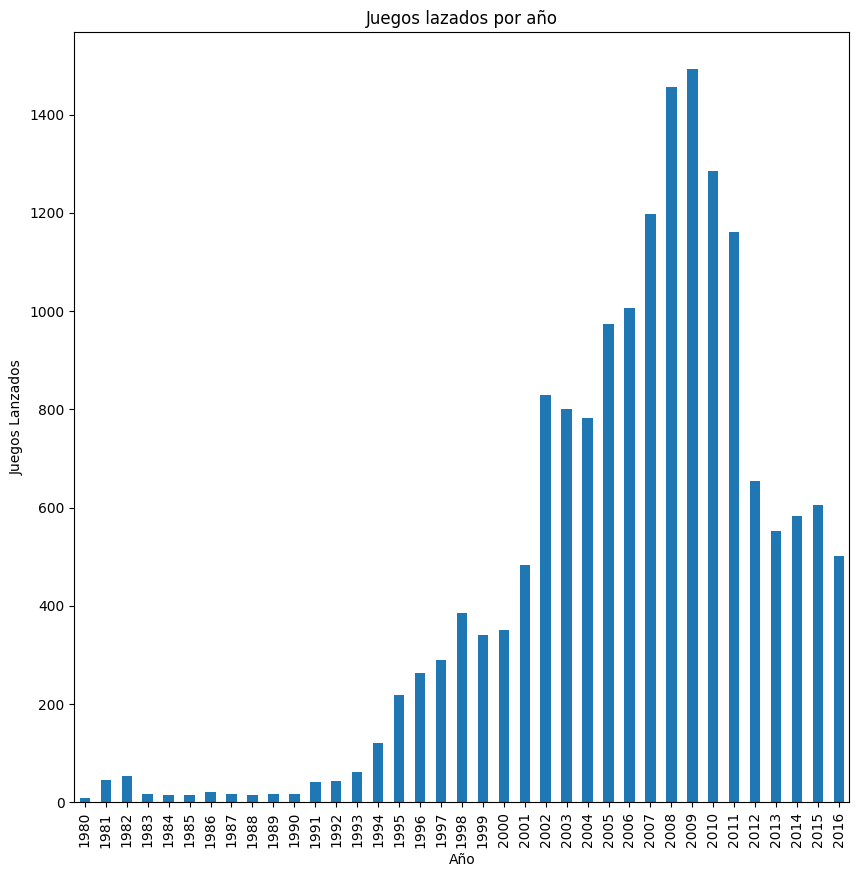

In [ ]:
juegos_anuales=df_games.groupby('year_of_release')['name'].count()
print(juegos_anuales)
juegos_anuales.plot(kind='bar',
                    title='Juegos lazados por año',
                    xlabel='Año',
                    ylabel='Juegos Lanzados',
                    figsize=[10, 10]
)
plt.show()

Hacemos un histograma para ver mejor la distribución

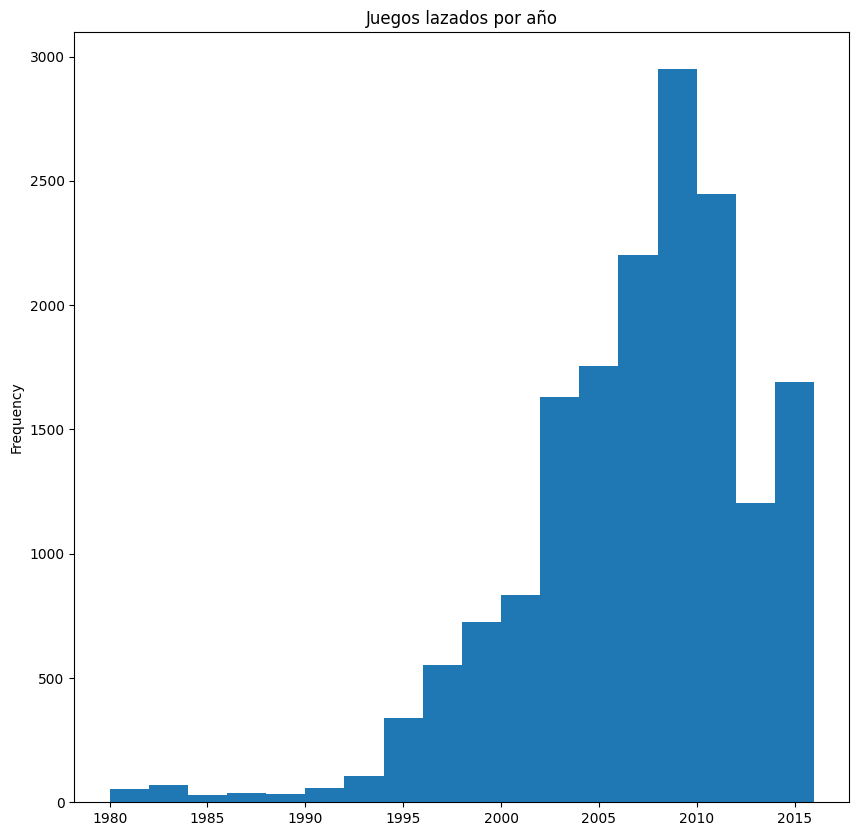

In [ ]:
df_games['year_of_release'].plot(kind='hist',
                    title='Juegos lazados por año',
                    xlabel='Año',
                    ylabel='Cantidad',
                    figsize=[10, 10],
                                 bins=18 #Use este número de bins para tener 1 bin por cada 2 años
)

plt.show()

Visualmente podríamos decir que los datos de 1995 hacia abajo los podemos desechar, veamos que porcentaje de la población representa el resto de la población

In [ ]:
juegos_anuales=juegos_anuales.reset_index()
juegos_anuales=juegos_anuales.rename(columns={'name':'total_games'})
top_years=juegos_anuales[juegos_anuales['year_of_release']>1995]
print(top_years)
conteo_top_years=top_years['total_games'].sum()
print(f'El total de juegos de 1996 en adelante es: {conteo_top_years}')
juegos_totales=juegos_anuales['total_games'].sum()
print(f'El total de juegos de todos los años es: {juegos_totales}')
print(f'El porcentaje de juegos de 1996 en adelante respecto al total es de: {(conteo_top_years/juegos_totales)*100}%')

    year_of_release  total_games
16             1996          264
17             1997          289
18             1998          386
19             1999          341
20             2000          350
21             2001          482
22             2002          829
23             2003          800
24             2004          783
25             2005          973
26             2006         1006
27             2007         1197
28             2008         1457
29             2009         1493
30             2010         1285
31             2011         1161
32             2012          653
33             2013          552
34             2014          582
35             2015          606
36             2016          502
El total de juegos de 1996 en adelante es: 15991
El total de juegos de todos los años es: 16715
El porcentaje de juegos de 1996 en adelante respecto al total es de: 95.66856117259947%


Redondeando, los juegos de 1996 a 2016 representan un 95.66% de la muestra. Hay que analizar otros temas como ventas, pero hasta ahora parece ser que el periodo de interes es 1996-2016

### Ventas por plataforma

Agrupamos por plataforma, revisamos sus ventas totales y graficamos para ver la distribución

platform
PCFX       0.03
GG         0.04
3DO        0.10
TG16       0.16
WS         1.42
NG         1.44
SCD        1.86
DC        15.95
GEN       30.77
SAT       33.59
PSV       54.07
WiiU      82.19
2600      96.98
XOne     159.32
GC       198.93
SNES     200.04
N64      218.68
NES      251.05
GB       255.46
XB       257.74
3DS      259.00
PC       259.52
PSP      294.05
PS4      314.14
GBA      317.85
PS       730.86
DS       806.12
Wii      907.51
PS3      939.65
X360     971.42
PS2     1255.77
Name: total_sales, dtype: float64


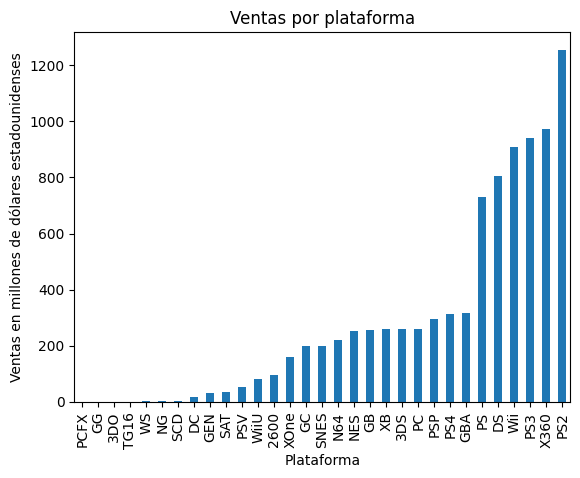

In [ ]:
ventas_plataforma=df_games.groupby('platform')['total_sales'].sum()
ventas_plataforma=ventas_plataforma.sort_values()
print(ventas_plataforma)
ventas_plataforma.plot(kind='bar',
                       title='Ventas por plataforma',
                       xlabel='Plataforma',
                       ylabel='Ventas en millones de dólares estadounidenses'
                      )

plt.show()

Ahora veamos el top 20 en ventas

In [ ]:
ventas_plataforma=ventas_plataforma.reset_index().sort_values(by='total_sales', ascending=False)
top_consolas=ventas_plataforma.head(20)
print(top_consolas)
ventas_top=(top_consolas['total_sales']).sum()
print(f'Las ventas del top 20 de consolas es de: {ventas_top}')
total_ventas=df_games['total_sales'].sum()
print(f'El porcentaje de ventas del top 20 vs el total es de {ventas_top/total_ventas*100} %')


   platform  total_sales
30      PS2      1255.77
29     X360       971.42
28      PS3       939.65
27      Wii       907.51
26       DS       806.12
25       PS       730.86
24      GBA       317.85
23      PS4       314.14
22      PSP       294.05
21       PC       259.52
20      3DS       259.00
19       XB       257.74
18       GB       255.46
17      NES       251.05
16      N64       218.68
15     SNES       200.04
14       GC       198.93
13     XOne       159.32
12     2600        96.98
11     WiiU        82.19
Las ventas del top 20 de consolas es de: 8776.279999999953
El porcentaje de ventas del top 20 vs el total es de 98.43613127838337 %


El top 20 de ventas por plataforma va desde el WiiU hasta el PS2 y representan un 98.43% de las ventas totales. Conservaremos este top 20 de ventas

### Ventas por plataforma y por año

Iniciemos el análisis por año y por plataforma filtrando los juegos del top 20

In [ ]:
top_20_ventas_anuales=df_games[df_games['platform'].isin(top_consolas['platform'])][['name', 'platform', 'year_of_release', 'total_sales']].groupby(['year_of_release', 'platform'])['total_sales'].sum()
top_20_ventas_anuales=top_20_ventas_anuales.reset_index()
top_20_ventas_anuales=top_20_ventas_anuales.pivot(index='year_of_release', columns='platform', values='total_sales').fillna(0)
print(top_20_ventas_anuales)

platform          2600    3DS      DS     GB    GBA     GC    N64    NES  \
year_of_release                                                            
1980             11.38   0.00    0.00   0.00   0.00   0.00   0.00   0.00   
1981             35.68   0.00    0.00   0.00   0.00   0.00   0.00   0.00   
1982             39.38   0.00    0.00   0.00   0.00   0.00   0.00   0.00   
1983              5.84   0.00    0.00   0.00   0.00   0.00   0.00  10.96   
1984              0.27   0.00    0.00   0.00   0.00   0.00   0.00  50.08   
1985              0.45   0.00    0.02   0.00   0.00   0.00   0.00  53.44   
1986              0.67   0.00    0.00   0.00   0.00   0.00   0.00  36.41   
1987              1.94   0.00    0.00   0.00   0.00   0.00   0.00  19.76   
1988              0.74   0.00    0.00   1.43   0.00   0.00   0.00  45.01   
1989              0.63   0.00    0.00  64.97   0.00   0.00   0.00   7.85   
1990              0.00   0.00    0.00   4.89   0.00   0.00   0.00  15.73   
1991        

Sustituí los datos ausentes por 0 ya que los datos ausentes correspondian a años en los que las consolas no estaban en el mercado. Graficamos las ventas anuales y calculamos el año de ventas máximas de cada consola del top

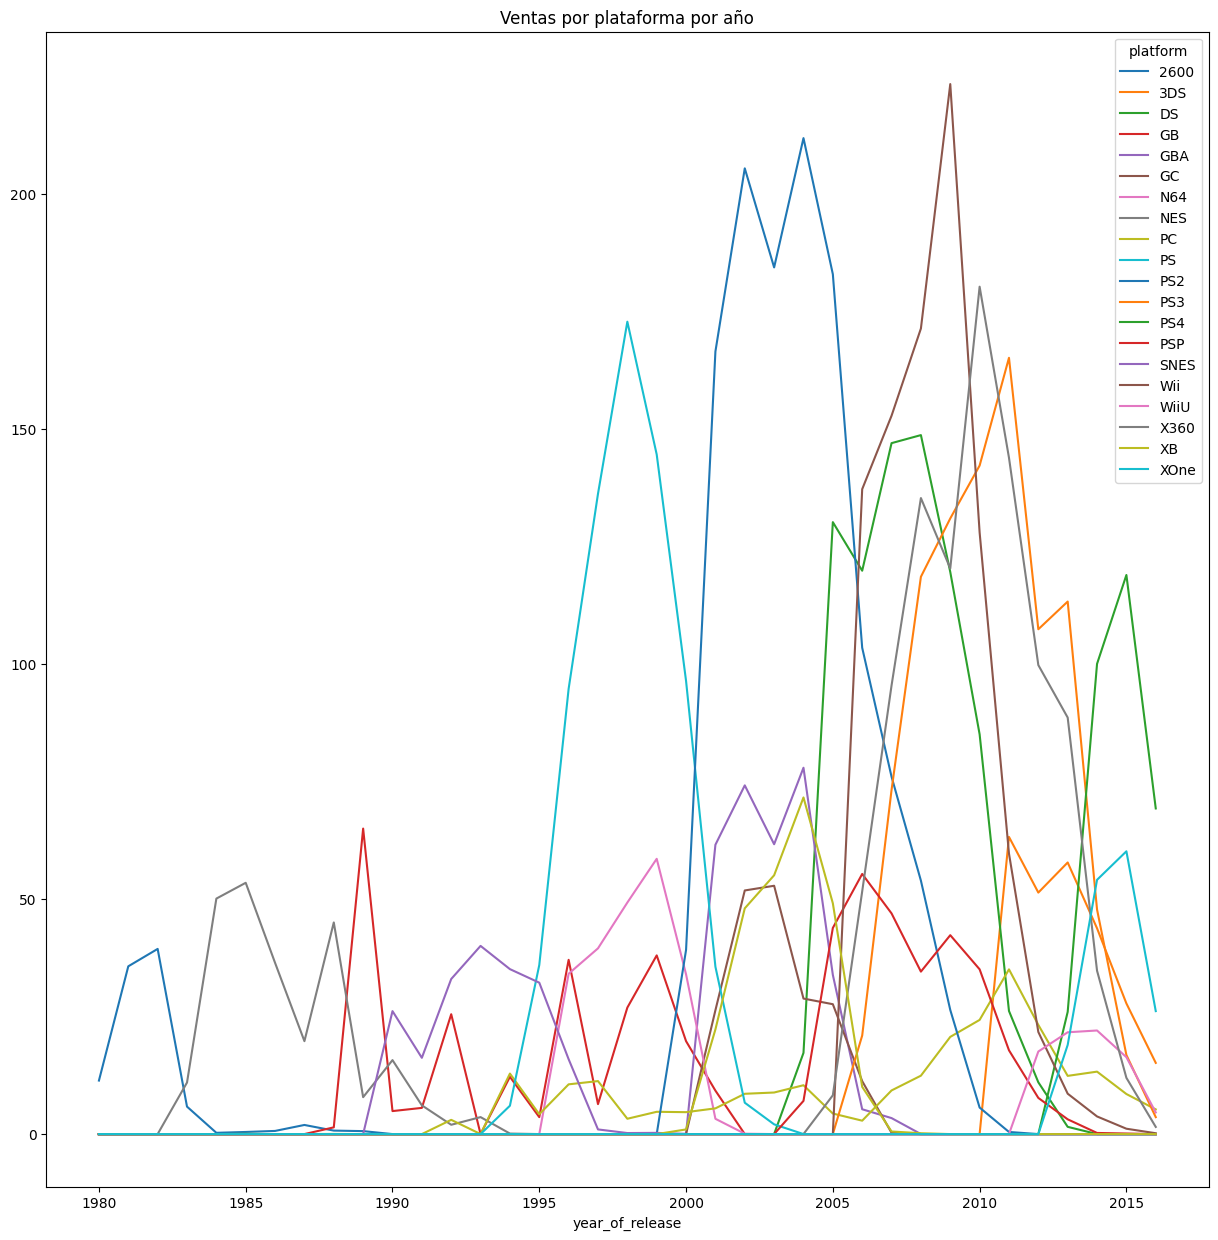

   platform  best_year
0      2600       1982
1       3DS       2011
2        DS       2008
3        GB       1989
4       GBA       2004
5        GC       2003
6       N64       1999
7       NES       1985
8        PC       2011
9        PS       1998
10      PS2       2004
11      PS3       2011
12      PS4       2015
13      PSP       2006
14     SNES       1993
15      Wii       2009
16     WiiU       2014
17     X360       2010
18       XB       2004
19     XOne       2015


In [ ]:
top_20_ventas_anuales.plot(kind='line',
                           figsize=[15,15],
                           title='Ventas por plataforma por año'
)
plt.show()
top_year=top_20_ventas_anuales.idxmax().reset_index()
top_year=top_year.rename(columns={0:'best_year'})
print(top_year)

### Tiempo de vida de consolas

Verificamos cual es el año de lanzamiento del primer y último juego de cada consola del top 20 y con eso calculamos su tiempo de vida

In [ ]:
first_year=df_games[['platform', 'year_of_release']].groupby('platform')['year_of_release'].min().reset_index()
first_year=first_year.rename(columns={'year_of_release': 'year_of_first_game'})
last_year=df_games[['platform', 'year_of_release']].groupby('platform')['year_of_release'].max().reset_index()
last_year=last_year.rename(columns={'year_of_release': 'year_of_last_game'})
years=first_year.merge(last_year, on='platform', how='left')
years['lifetime']=years['year_of_last_game']-years['year_of_first_game']
years=years[years['platform'].isin(top_consolas['platform'])]
print(years)

   platform  year_of_first_game  year_of_last_game  lifetime
0      2600                1980               1989         9
2       3DS                2011               2016         5
4        DS                1985               2013        28
5        GB                1988               2001        13
6       GBA                2000               2007         7
7        GC                2001               2007         6
10      N64                1996               2002         6
11      NES                1983               1994        11
13       PC                1985               2016        31
15       PS                1994               2003         9
16      PS2                2000               2011        11
17      PS3                2006               2016        10
18      PS4                2013               2016         3
19      PSP                2004               2015        11
23     SNES                1990               1999         9
26      Wii             

Ordenamos las consolas de más antigua a más nueva y filtramos unicamente las que están en el top de ventas

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Genial! Muy buen trabajo con las ventas por plataforma y los juegos lanzados por año. Además, se puede reconocer estos picos de diferentes plataformas de video juegos en las épocas datadas. Buen trabajo!
</div>

In [ ]:
years=years.sort_values(by='year_of_first_game', ascending=True)
print(years)


   platform  year_of_first_game  year_of_last_game  lifetime
0      2600                1980               1989         9
11      NES                1983               1994        11
4        DS                1985               2013        28
13       PC                1985               2016        31
5        GB                1988               2001        13
23     SNES                1990               1999         9
15       PS                1994               2003         9
10      N64                1996               2002         6
6       GBA                2000               2007         7
29       XB                2000               2008         8
16      PS2                2000               2011        11
7        GC                2001               2007         6
19      PSP                2004               2015        11
28     X360                2005               2016        11
17      PS3                2006               2016        10
26      Wii             

La fecha de inicio de ventas de las consolas va desde 1980 a 2013, hay 33 años de diferencia, hagamos un análisis dividiendo en grupos de 11 años. Dejaré fuera a PC debido a que es una consola que sigue vigente.

In [ ]:
grupo_1=years[(years['year_of_first_game']<1991) & (~(years['platform']=='PC'))]
print(grupo_1)
grupo_2=years[(years['year_of_first_game']>=1991) & (years['year_of_first_game']<2002)]
print(grupo_2)
grupo_3=years[(years['year_of_first_game']>=2002)]
print(grupo_3)

   platform  year_of_first_game  year_of_last_game  lifetime
0      2600                1980               1989         9
11      NES                1983               1994        11
4        DS                1985               2013        28
5        GB                1988               2001        13
23     SNES                1990               1999         9
   platform  year_of_first_game  year_of_last_game  lifetime
15       PS                1994               2003         9
10      N64                1996               2002         6
6       GBA                2000               2007         7
29       XB                2000               2008         8
16      PS2                2000               2011        11
7        GC                2001               2007         6
   platform  year_of_first_game  year_of_last_game  lifetime
19      PSP                2004               2015        11
28     X360                2005               2016        11
17      PS3             

Calculo la media y mediana del tiempo de vida del primer grupo

In [ ]:
media_grupo_1=grupo_1['lifetime'].mean()
mediana_grupo_1=grupo_1['lifetime'].median()
print(f'La media del grupo de consolas que nació entre 1980 y 1990 es: {media_grupo_1} años. La mediana es: {mediana_grupo_1}')

La media del grupo de consolas que nació entre 1980 y 1990 es: 14.0 años. La mediana es: 11.0


Calculo la media y mediana del tiempo de vida del segundo grupo

In [ ]:
media_grupo_2=grupo_2['lifetime'].mean()
mediana_grupo_2=grupo_2['lifetime'].median()

print(f'La media del grupo de consolas que nació entre 1991 y 2001 es: {media_grupo_2} años. La mediana es: {mediana_grupo_2} ')

La media del grupo de consolas que nació entre 1991 y 2001 es: 7.833333333333333 años. La mediana es: 7.5 


Calculo la media y mediana del tiempo de vida del tercer grupo

In [ ]:
media_grupo_3=grupo_3['lifetime'].mean()
mediana_grupo_3=grupo_3['lifetime'].median()

print(f'La media del grupo de consolas que nació después de 2001 es: {media_grupo_3} años. La mediana es: {mediana_grupo_3}')

La media del grupo de consolas que nació después de 2001 es: 7.125 años. La mediana es: 7.5


Vemos que tanto la media como la mediana para el grupo 1 son mayores respecto a los otros grupos.
El grupo 3 tiene consolas que es posible que se sigan comercializando, de la única que podemos estar seguros que ya no comercializa juegos es PSP porque el último juego salió en 2015, el resto tienen juegos en 2016, no sabemos si es su último año o si haya nuevos juegos en 2017.
Con los datos obtenidos, podemos concluir que las primeras consolas tendían a tener tiempos de vida mayores, seguramente debido a que la tecnología para crear consolas no estaba tan disponible como en tiempos actuales. Los grupos 2 y 3 tienen tiempos de vida muy similares (entre 7 y 8 años) de acuerdo a los datos obtenidos, pero de nuevo, hay que recordar que no sabemos con certeza si alguna consola con ventas en 2016 siga vigente o no.

### Definición de periodo de interés

Con lo visto anteriormente, es momento de revisar todos los resultados y definir el periodo a utilizar para el análisis y la estrategia para 2017. Los útlimos cálculos realizado en el punto anterior nos indican que el tiempo de vida de las consolas es de entre 7 y 8 años, por lo que si queremos realizar una estrategia para 2017 sería importante considerar las consolas 'vivas'. Adicional hagamos una revisión el 'pico' de ventas de las consolas del top.

In [ ]:
top_year=top_year.merge(years[['platform', 'year_of_first_game']], on='platform', how='left')
print(top_year)

   platform  best_year  year_of_first_game
0      2600       1982                1980
1       3DS       2011                2011
2        DS       2008                1985
3        GB       1989                1988
4       GBA       2004                2000
5        GC       2003                2001
6       N64       1999                1996
7       NES       1985                1983
8        PC       2011                1985
9        PS       1998                1994
10      PS2       2004                2000
11      PS3       2011                2006
12      PS4       2015                2013
13      PSP       2006                2004
14     SNES       1993                1990
15      Wii       2009                2006
16     WiiU       2014                2012
17     X360       2010                2005
18       XB       2004                2000
19     XOne       2015                2013


Restamos el año de máximas ventas menos el año de nacimiento de cada consola

In [ ]:
top_year['time_to_peak']=top_year['best_year']-top_year['year_of_first_game']
top_year=top_year.sort_values(by='year_of_first_game', ascending=True)
print(top_year)

   platform  best_year  year_of_first_game  time_to_peak
0      2600       1982                1980             2
7       NES       1985                1983             2
2        DS       2008                1985            23
8        PC       2011                1985            26
3        GB       1989                1988             1
14     SNES       1993                1990             3
9        PS       1998                1994             4
6       N64       1999                1996             3
4       GBA       2004                2000             4
18       XB       2004                2000             4
10      PS2       2004                2000             4
5        GC       2003                2001             2
13      PSP       2006                2004             2
17     X360       2010                2005             5
11      PS3       2011                2006             5
15      Wii       2009                2006             3
1       3DS       2011         

Calculamos la mediana debido a que hay datos atípicos tanto arriba como abajo en las consolas DS, PC y 3DS

In [ ]:
mediana=top_year['time_to_peak'].median()
print(mediana)

3.0


Podemos decir que una consola tarda aproximadamente 3 años desde su nacimiento en llegar a su pico de ventas. Considerando esto, vemos que las consolas que estarían cercanas a su tope más alto de ventas en 2017 son: PS4 y XOne. La estrategia debería considerarlas fuertemente, adicionalmente hay que considerar a las consolas que siguen vivas, para eso veamos cuales han tenido ventas en 2016 y un tiempo de vida menor de 8 años

In [ ]:
print(years[(years['year_of_last_game']==2016)&(years['lifetime']<8)])

   platform  year_of_first_game  year_of_last_game  lifetime
2       3DS                2011               2016         5
27     WiiU                2012               2016         4
18      PS4                2013               2016         3
30     XOne                2013               2016         3



Importante aclarar que la PC aunque no aparece en la lista anterior porque tiene 26 años viva, se debe considerar en la lista final. Con esto, y con los datos anteriores, podemos decir que las consolas más interesantes para analizar son:
PC
3DS
WiiU
PS4
XOne
Y los años de interés serán lo que han vivido estas consolas, osea de 2011 en adelante. Es importante aclarar que se consideraran juegos de todas las consolas con ventas en el período establecido en análisis posteriores, aunque quizás alguna consola ya no esté a la venta, las tendencias de compra de juegos pueden ayudar a definir algún género, calificación de la crítica, etc.
El siguiente paso es obtener el dataframe con el que trabajaremos de ahora en adelante, partiendo del periodo de interés

In [ ]:
df_filtrado=df_games[df_games['year_of_release']>=2011]
print(df_filtrado)

                                 name platform  year_of_release         genre  \
16                 Grand Theft Auto V      PS3             2013        Action   
23                 Grand Theft Auto V     X360             2013        Action   
29     Call of Duty: Modern Warfare 3     X360             2011       Shooter   
31          Call of Duty: Black Ops 3      PS4             2015       Shooter   
33                Pokemon X/Pokemon Y      3DS             2013  Role-Playing   
...                               ...      ...              ...           ...   
16703                Strawberry Nauts      PSV             2016     Adventure   
16707                Aiyoku no Eustia      PSV             2014          Misc   
16710   Samurai Warriors: Sanada Maru      PS3             2016        Action   
16712         Haitaka no Psychedelica      PSV             2016     Adventure   
16714             Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  

### Ventas en el periodo de interés

Ahora veamos las ventas por consola y por año en el periodo de tiempo elegido

In [ ]:
ventas_anuales=df_filtrado.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
ventas_anuales=ventas_anuales.pivot(index='year_of_release', columns='platform', values='total_sales').fillna(0)
print(ventas_anuales)

platform           3DS     DS     PC   PS2     PS3     PS4    PSP    PSV  \
year_of_release                                                            
2011             63.20  26.18  35.03  0.45  165.09    0.00  17.82   4.63   
2012             51.36  11.01  23.22  0.00  107.36    0.00   7.69  16.19   
2013             57.76   1.54  12.38  0.00  113.25   25.99   3.14  10.59   
2014             43.76   0.00  13.28  0.00   47.76  100.00   0.24  12.16   
2015             27.78   0.00   8.52  0.00   16.82  118.90   0.12   6.25   
2016             15.14   0.00   5.25  0.00    3.60   69.25   0.00   4.25   

platform           Wii   WiiU    X360   XOne  
year_of_release                               
2011             59.65   0.00  143.84   0.00  
2012             21.71  17.56   99.74   0.00  
2013              8.59  21.65   88.58  18.96  
2014              3.75  22.03   34.74  54.07  
2015              1.14  16.35   11.96  60.14  
2016              0.18   4.60    1.52  26.15  


Creamos el gráfico de cajas

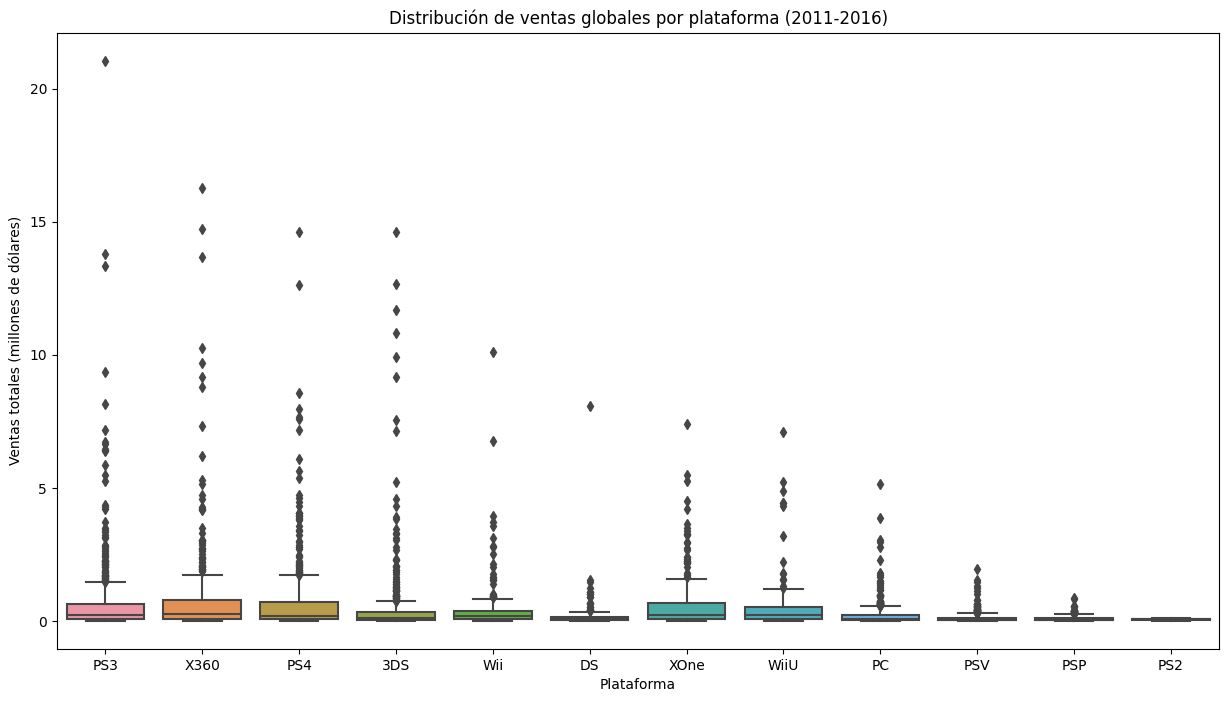

In [ ]:
plt.figure(figsize=[15, 8])
sns.boxplot(data=df_filtrado, x='platform', y='total_sales')
plt.title('Distribución de ventas globales por plataforma (2011-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones de dólares)')
plt.show()

El gráfico muestra muchos valores atípicos por encima del bigote superior, teniendo un top 4 en ventas con PS3, X360, PS4 y 3DS. Vemos que la mediana es relativamente similar desde PS3 hasta WiiU, lo que me da a entender que debe de haber juegos en plataformas específicas con altas ventas que son los que mueven el resultado global. Visualmente la media es superior a la mediana, esto debido al número tan alto de outliers por encima de las cajas. Hagamos un análisis de medianas y medias a continuación

In [ ]:
resumen_ventas = df_filtrado.groupby('platform')['total_sales'].agg(['mean', 'median']).sort_values('mean', ascending=False)
print(resumen_ventas)

              mean  median
platform                  
PS4       0.801378   0.200
X360      0.763815   0.270
XOne      0.645020   0.220
PS3       0.619209   0.210
WiiU      0.559116   0.220
3DS       0.498077   0.120
Wii       0.482335   0.170
PC        0.251105   0.080
DS        0.210489   0.080
PSV       0.125744   0.055
PSP       0.092981   0.040
PS2       0.064286   0.060


Las medianas como vimos son relativamente similares, sin embargo es en las medias donde hay mayor diferencia. Hacemos un gráfico de barras para tener una visión más clara del comportamiento anual

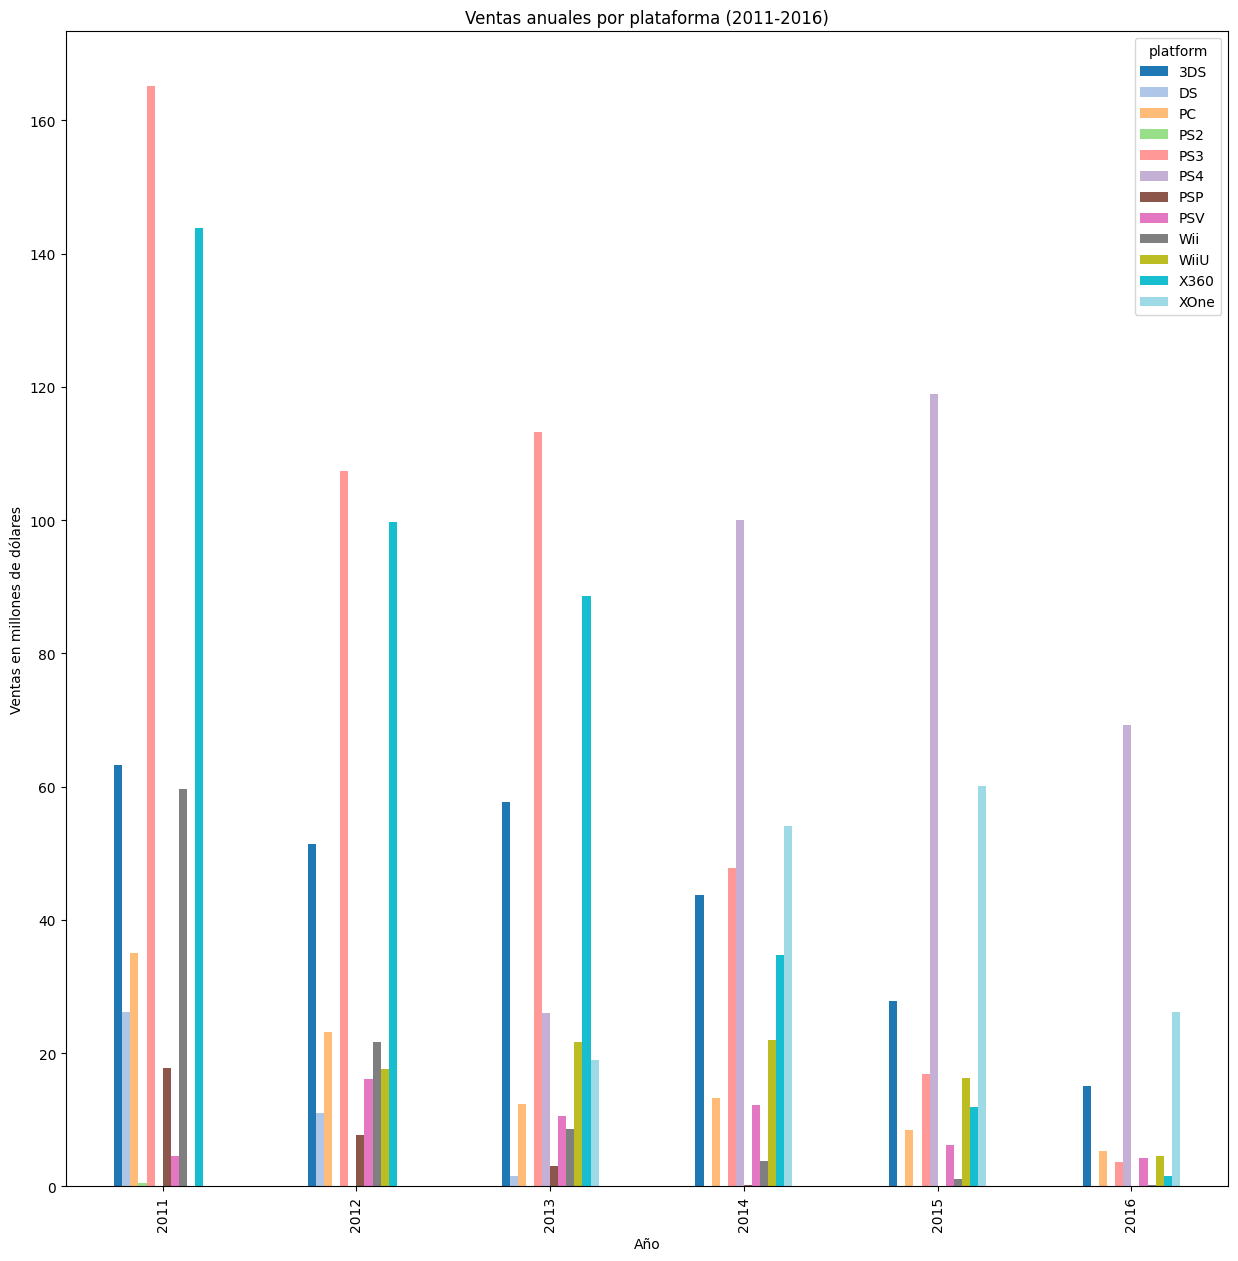

In [ ]:
ventas_anuales.plot(kind='bar',
                    title='Ventas anuales por plataforma (2011-2016)',
                    figsize=[15, 15],
                    xlabel='Año',
                    ylabel='Ventas en millones de dólares',
                    colormap='tab20'
                   )
plt.show()


Notamos un dominio en los primeros 3 años por parte de PS3, a partir de 2014 el nuevo líder es PS4 (relevo generacional de PS3).
X360 es un sólido segundo lugar entre 2011-2013, siendo superado por XOne a partir de 2014, mismo fenómeno que con PS, la nueva generación desplaza a la anterior.
3DS tiene un desempeño un poco más estable, manteniendo ventas entre 40-70 millones de 2011 a 2014, en 2015 se pronuncia un poco más su bajada, sin embargo mantiene el tercer puesto durante prácticamente todo el periodo, con excepción en 2014 donde la salida a mercado de plataformas de la competencia hacen que ocupe el cuarto lugar.
El siguiente competidor sería Wii, vemos que baja aceleradamente entre 2011 y 2012, año en el que sale a mercado su sucesor WiiU.
El caso de WiiU es distinto a los anteriores ya que su pico de ventas esta apenas por encima de los 20 millones entre 2013 y 2014, marcando un declive a partir de 2015.
Para el caso de PC vemos una caída practicamente lineal, arrancando con su nivel más alto el 2011 y su peor año en 2016. Esto puede ser un indicador de tendencia, los jugadores actuales prefieren las consolas de nueva generación sobre una computadora.
Para DS vemos que en 2011 convive con su sucesor, sin embargo sus ventas se desploman y dejar de ser visibles a partir de 2014.
PS2 vemos un pequeño remanente en 2011, pero sus ventas ya no son significativas.
PSV es un caso similar a WiiU, con ventas más modestas, teniendo su mejor año en 2012, manteniendo algo de ventas hasta 2016 pero con tendencia bajista.
PSP vemos su mejor año en 2011, pero empieza a convivir con su sucesor, esto provoca que a partir de 2012 sus ventas se vean opacadas.
Viendo las ventas anuales por consola, los datos de medias y gráfico de cajas, y los relevos generacionales, puedo decir que las plataformas a considerar son PS4 y XOne, 3DS aunque sigue sólido de acuerdo a análisis anteriores es probable que se encuentre al final de su vida, pero sigue teniendo ventas importantes por lo que debe considerarse,y al final también consideraría a PC ya que siempre está vigente y el mercado puede cambiar sin previo aviso.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Tu elección de rango temporal para el analisis es muy valida, la decisión basada en las plataformas más relevantes para el periodo de analisis es muy buena. Además, un periodo no mayor de 5 años es la mejor eleccion en este caso dada la alta variabilidad del comportamiento de las tecnologias emergentes en la ultima decada.
Excelente trabajo con el analisis por plataforma para el periodo elegido. El grafico de cajas está correcto, bien hecho al poner limites en el eje Y que permitan observar mejor la distribucion por plataforma sin darle tanta importancia a los outliers.
</div>

### Relación entre reseñas y ventas

Agrupemos los juegos de PS4 (líder en ventas al momento)

In [ ]:
juegos_ps4=df_filtrado[df_filtrado['platform']=='PS4']

Creamos el gráfico de dispersión para ver la correlación

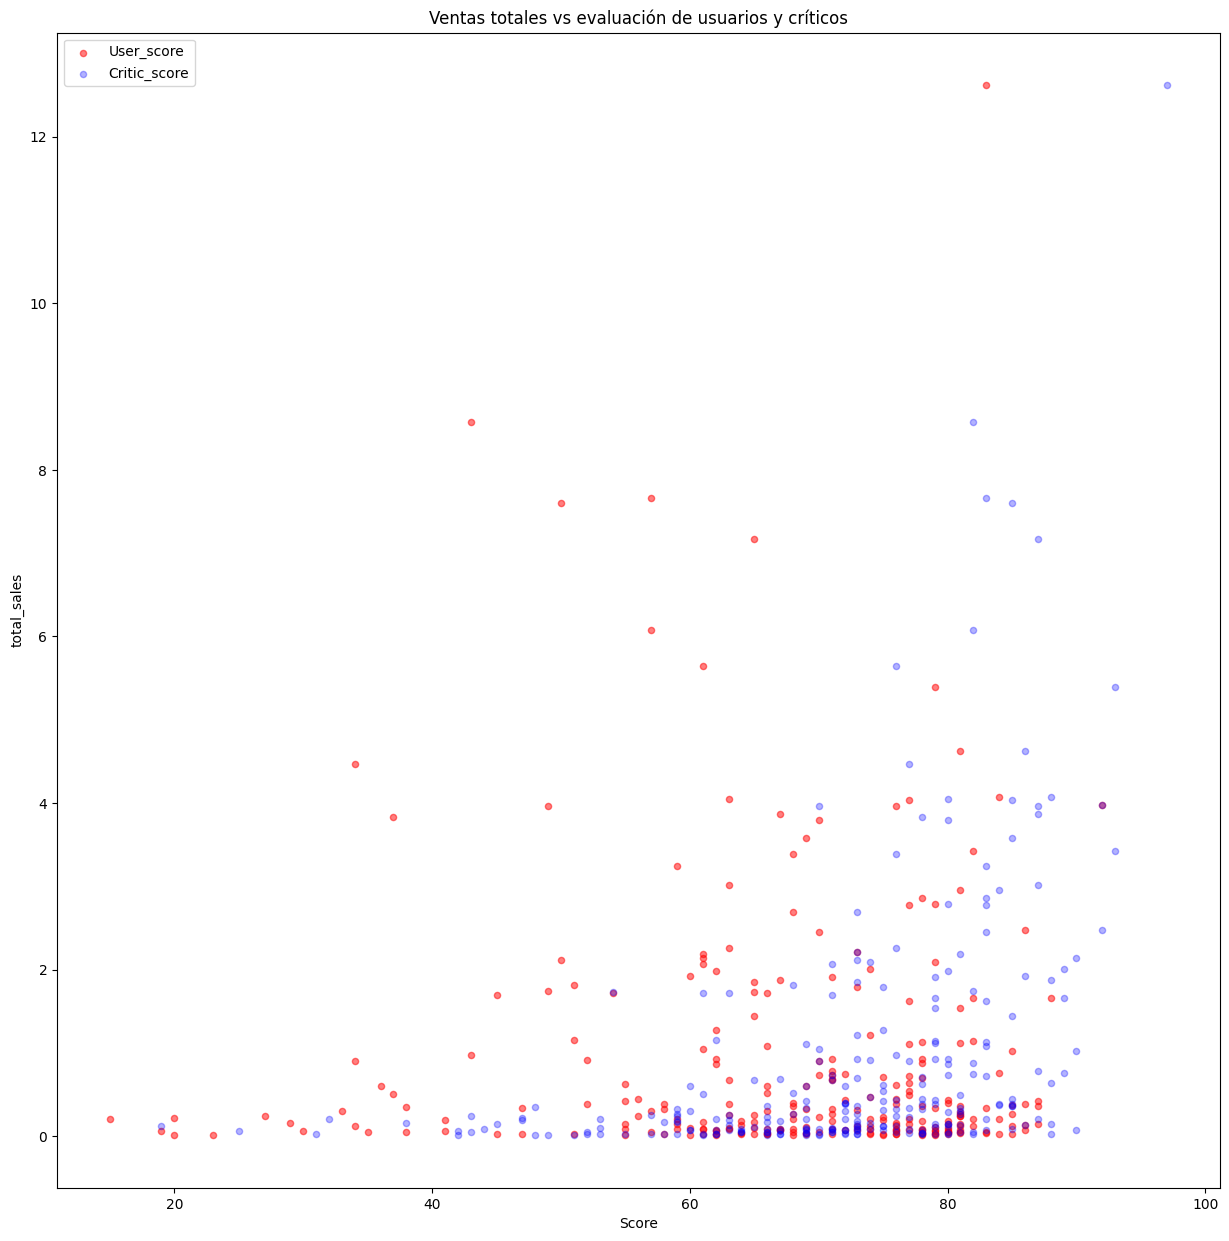

In [ ]:
fig, ax = plt.subplots(figsize=[15,15])
juegos_ps4.plot(kind='scatter',
                   xlabel='Score',
                   ylabel='Ventas en millones de dólares',
                   title='Ventas totales vs evaluación de usuarios y críticos',
                   x='user_score',
                   y='total_sales',
                   ax=ax,
                   color= 'red',
                   label='User_score',
                alpha=0.5
                  )
juegos_ps4.plot(kind='scatter',
                   x='critic_score',
                   y='total_sales',
                     color='blue',
                     label='Critic_score',
                xlabel='Score',
                alpha=0.3,
                    ax=ax)
plt.legend()
plt.show()

Visualmente se aprecia mucha dispersión en los puntos, pero hagamos la comprobación haciendo los cálculos

In [ ]:
correlacion=juegos_ps4[['user_score', 'total_sales', 'critic_score']].corr()
print(f'La correlacion de la evaluación vs las ventas totales es de: \n{correlacion}')

La correlacion de la evaluación vs las ventas totales es de: 
              user_score  total_sales  critic_score
user_score      1.000000    -0.031957      0.557654
total_sales    -0.031957     1.000000      0.406568
critic_score    0.557654     0.406568      1.000000


Vemos una correlación no muy fuerte para ambas evaluaciones, sin embargo es bastante más grande la correlación para la evaluación de los críticos (0.40 vs -0.03) por lo que podemos asegurar que la calificación de la crítica tiene un mayor impacto en las ventas totales que la evaluación de los usuarios. La evaluación de los usuarios tiene una correlación muy cercana a 0, por lo que podemos decir que no tiene un impacto en las ventas.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente trabajo con el analisis de correlaciones de reseñas y ventas. Como mencionas para las diferentes plataformas abordadas, las reseñas de críticos representan una mayor influencia en las ventas, lo cual permite abrir pruebas posteriores para estudiar la causalidad entre ambas variables y con ello poder tomar acciones de negocio.

### Juegos multiplataforma

Identificamos los juegos que se comercializaron en más de una plataforma

In [ ]:
juegos_multiplataforma=df_filtrado[df_filtrado['name'].duplicated(keep=False)][['name', 'platform', 'total_sales']]
print(juegos_multiplataforma)

                                                name platform  total_sales
16                                Grand Theft Auto V      PS3        21.05
23                                Grand Theft Auto V     X360        16.27
29                    Call of Duty: Modern Warfare 3     X360        14.73
31                         Call of Duty: Black Ops 3      PS4        14.63
34                        Call of Duty: Black Ops II      PS3        13.79
...                                              ...      ...          ...
16672  Metal Gear Solid V: The Definitive Experience     XOne         0.01
16691                   Dynasty Warriors: Eiketsuden      PS3         0.01
16692              Metal Gear Solid V: Ground Zeroes       PC         0.01
16710                  Samurai Warriors: Sanada Maru      PS3         0.01
16714                            Winning Post 8 2016      PSV         0.01

[2410 rows x 3 columns]


Hacemos una tabla para ver todos los juegos con sus respectivas consolas

In [ ]:
juegos_multiplataforma_tabla=juegos_multiplataforma.pivot_table(index='name', columns='platform', values='total_sales')
print(juegos_multiplataforma_tabla)

platform                              3DS    DS    PC  PS2   PS3   PS4  PSP  \
name                                                                          
 Frozen: Olaf's Quest                0.59  0.51   NaN  NaN   NaN   NaN  NaN   
2014 FIFA World Cup Brazil            NaN   NaN   NaN  NaN  0.61   NaN  NaN   
3rd Super Robot Wars Z Jigoku Hen     NaN   NaN   NaN  NaN  0.23   NaN  NaN   
3rd Super Robot Wars Z: Tengoku-Hen   NaN   NaN   NaN  NaN  0.15   NaN  NaN   
7 Days to Die                         NaN   NaN   NaN  NaN   NaN  0.14  NaN   
...                                   ...   ...   ...  ...   ...   ...  ...   
Zumba Fitness Core                    NaN   NaN   NaN  NaN   NaN   NaN  NaN   
Zumba Fitness: World Party            NaN   NaN   NaN  NaN   NaN   NaN  NaN   
[Prototype 2]                         NaN   NaN  0.11  NaN  0.74   NaN  NaN   
de Blob 2                             NaN  0.11   NaN  NaN  0.21   NaN  NaN   
uDraw Studio: Instant Artist          NaN   NaN   Na

Vamos a hacer la comparación de PS4 vs el resto, para ello filtramos únicamente los juegos que fueron lanzados para PS4. Dejamos los NaN para futuros calculos

In [ ]:
juegos_multiplataforma_tabla=juegos_multiplataforma_tabla[juegos_multiplataforma_tabla['PS4'].notna()]
print(juegos_multiplataforma_tabla)

platform                                     3DS  DS  PC  PS2   PS3   PS4  \
name                                                                        
7 Days to Die                                NaN NaN NaN  NaN   NaN  0.14   
Adventure Time: Finn & Jake Investigations  0.09 NaN NaN  NaN  0.08  0.10   
Aegis of Earth: Protonovus Assault           NaN NaN NaN  NaN  0.02  0.02   
Agatha Christie's The ABC Murders            NaN NaN NaN  NaN   NaN  0.02   
Akiba's Trip: Undead & Undressed             NaN NaN NaN  NaN  0.11  0.11   
...                                          ...  ..  ..  ...   ...   ...   
Yakuza Zero: The Place of Oath               NaN NaN NaN  NaN  0.25  0.17   
Yakuza: Ishin                                NaN NaN NaN  NaN  0.26  0.15   
Yoru no Nai Kuni                             NaN NaN NaN  NaN  0.05  0.08   
ZombiU                                       NaN NaN NaN  NaN   NaN  0.06   
Zombie Army Trilogy                          NaN NaN NaN  NaN   NaN  0.20   

Calculamos el total de ventas de cada título

In [ ]:
juegos_multiplataforma_tabla['total_sales']=juegos_multiplataforma_tabla.sum(axis=1)
print(juegos_multiplataforma_tabla)

platform                                     3DS  DS  PC  PS2   PS3   PS4  \
name                                                                        
7 Days to Die                                NaN NaN NaN  NaN   NaN  0.14   
Adventure Time: Finn & Jake Investigations  0.09 NaN NaN  NaN  0.08  0.10   
Aegis of Earth: Protonovus Assault           NaN NaN NaN  NaN  0.02  0.02   
Agatha Christie's The ABC Murders            NaN NaN NaN  NaN   NaN  0.02   
Akiba's Trip: Undead & Undressed             NaN NaN NaN  NaN  0.11  0.11   
...                                          ...  ..  ..  ...   ...   ...   
Yakuza Zero: The Place of Oath               NaN NaN NaN  NaN  0.25  0.17   
Yakuza: Ishin                                NaN NaN NaN  NaN  0.26  0.15   
Yoru no Nai Kuni                             NaN NaN NaN  NaN  0.05  0.08   
ZombiU                                       NaN NaN NaN  NaN   NaN  0.06   
Zombie Army Trilogy                          NaN NaN NaN  NaN   NaN  0.20   

Calculamos el porcentaje que representa PS4 en esas ventas

In [ ]:
juegos_multiplataforma_tabla['share_PS4']=juegos_multiplataforma_tabla['PS4']/juegos_multiplataforma_tabla['total_sales']*100
print(juegos_multiplataforma_tabla)

platform                                     3DS  DS  PC  PS2   PS3   PS4  \
name                                                                        
7 Days to Die                                NaN NaN NaN  NaN   NaN  0.14   
Adventure Time: Finn & Jake Investigations  0.09 NaN NaN  NaN  0.08  0.10   
Aegis of Earth: Protonovus Assault           NaN NaN NaN  NaN  0.02  0.02   
Agatha Christie's The ABC Murders            NaN NaN NaN  NaN   NaN  0.02   
Akiba's Trip: Undead & Undressed             NaN NaN NaN  NaN  0.11  0.11   
...                                          ...  ..  ..  ...   ...   ...   
Yakuza Zero: The Place of Oath               NaN NaN NaN  NaN  0.25  0.17   
Yakuza: Ishin                                NaN NaN NaN  NaN  0.26  0.15   
Yoru no Nai Kuni                             NaN NaN NaN  NaN  0.05  0.08   
ZombiU                                       NaN NaN NaN  NaN   NaN  0.06   
Zombie Army Trilogy                          NaN NaN NaN  NaN   NaN  0.20   

Calculamos la media y la mediana de esa proporción de ventas de PS4

In [ ]:
media=juegos_multiplataforma_tabla['share_PS4'].mean()
mediana=juegos_multiplataforma_tabla['share_PS4'].median()
print(f'La media es: {media} y la mediana es: {mediana}')

La media es: 48.70225200726884 y la mediana es: 50.0


Después de calcular, podemos ver que alrededor del 50% de las ventas viene de PS4, si bien este dato podría ser determinante porque tenemos una lista de muchas consolas, la realidad es que matemáticamente no podemos asegurar aún que las ventas dependen más de la plataforma que del juego en sí, ya que si todos los juegos estuvieran presentes unicamente en 2 consolas no tendríamos algo determinante, por lo que calcularé el promedio de ventas de cada juego sin considerar las ventas de PS4, de esa manera puedo comparar las ventas de PS4 vs el promedio de las otras consolas y ver cual es mayor

In [ ]:
juegos_multiplataforma_tabla['average_sales']=(juegos_multiplataforma_tabla.drop(['PS4', 'total_sales', 'share_PS4'], axis=1)).mean(axis=1)
print(juegos_multiplataforma_tabla)

platform                                     3DS  DS  PC  PS2   PS3   PS4  \
name                                                                        
7 Days to Die                                NaN NaN NaN  NaN   NaN  0.14   
Adventure Time: Finn & Jake Investigations  0.09 NaN NaN  NaN  0.08  0.10   
Aegis of Earth: Protonovus Assault           NaN NaN NaN  NaN  0.02  0.02   
Agatha Christie's The ABC Murders            NaN NaN NaN  NaN   NaN  0.02   
Akiba's Trip: Undead & Undressed             NaN NaN NaN  NaN  0.11  0.11   
...                                          ...  ..  ..  ...   ...   ...   
Yakuza Zero: The Place of Oath               NaN NaN NaN  NaN  0.25  0.17   
Yakuza: Ishin                                NaN NaN NaN  NaN  0.26  0.15   
Yoru no Nai Kuni                             NaN NaN NaN  NaN  0.05  0.08   
ZombiU                                       NaN NaN NaN  NaN   NaN  0.06   
Zombie Army Trilogy                          NaN NaN NaN  NaN   NaN  0.20   

Promediamos los promedios calculados y comparamos contra el promedio de las ventas de PS4

In [ ]:

promedio_otros=juegos_multiplataforma_tabla['average_sales'].mean()
promedio_ps4=juegos_multiplataforma_tabla['PS4'].mean()
print(f'El promedio de ventas de PS4 es: {promedio_ps4} y el promedio del resto de plataformas es: {promedio_otros}')


El promedio de ventas de PS4 es: 0.8843354430379748 y el promedio del resto de plataformas es: 0.44243045509342976


El resultado de solo PS4 es mayor que el promedio de sus competidores para la misma lista de juegos, por lo tanto podemos concluir que es más probable que un usuario compre juegos de PS4 aún estando disponibles para otras consolas, y esto tiene sentido ya que al ser la líder en venta de juegos seguramente es la que tiene un mayor número de clientes, esto también hace más probable que compren un juego para la consola que tienen.

### Ventas por género

Agrupamos para ver las ventas por género, el total de juegos y el promedio de venta por cada uno

In [ ]:
ventas_genero = df_filtrado.groupby('genre')['total_sales'].agg(['sum', 'count']).reset_index()
ventas_genero = ventas_genero.rename(columns={'sum': 'total_sales', 'count': 'total_games'})
ventas_genero['average'] = ventas_genero['total_sales'] / ventas_genero['total_games']
ventas_genero = ventas_genero.sort_values(by='total_sales', ascending=False).reset_index(drop=True)
print(ventas_genero)

           genre  total_sales  total_games   average
0         Action       561.92         1277  0.440031
1        Shooter       403.23          331  1.218218
2   Role-Playing       245.98          469  0.524478
3         Sports       237.80          393  0.605089
4           Misc       141.35          378  0.373942
5         Racing        89.22          183  0.487541
6       Platform        89.16          123  0.724878
7       Fighting        66.90          159  0.420755
8     Simulation        50.82          139  0.365612
9      Adventure        45.16          413  0.109346
10      Strategy        22.33          119  0.187647
11        Puzzle        10.00           72  0.138889


Con esto tenemos una visión completa del comportamiento de las ventas de acuerdo al género de los juegos, el top de géneros que debemos considerar es:
Action: género líder en ventas, muy impulsado por la cantidad de juegos existentes. Su promedio de ventas por juego es bajo comparado con el resto de géneros top, por lo que hay que considerar esto en la estrategia.
Shooter: El género ganador de acuerdo al análisis, tienen el promedio de ventas más alto por título, por lo que son éxitos prácticamente asegurados (el público disfruta este género)
Role-Playing: Es un género que vende, pero tiene muchos títulos, a pesar de la alta competencia, mantiene buen desempeño promedio.
Sports: Tiene un buen promedio de ventas y buenas ventas totales, es una opción sólida.

Para los 2 géneros menos vendidos, una hipótesis personal es que son géneros que buscan más el razonamiento de los usuarios que la habilidad, y al parecer no a todo el público le gustan este tipo de juegos. Si incluimos el género de 'Adventure' podemos ver que son 3 géneros que en promedio venden abajo de 200 mil dólares por título, son los menos redituables de la tabla. Esto también debe considerarse en la estrategia final.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Muy buen trabajo con la graficacion para el analisis de juegos multiplataforma, al igual que para las ventas por género. De forma ordenada has dado a entender las tendencias principales y también los nichos de mercado que se pueden estudiar o aprovechar en la toma de acciones de negocio.

## Paso 4. Crea un perfil de usuario para cada región

### Top 5 Consolas por región

In [ ]:
consolas_na=df_filtrado.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5).reset_index()
print(consolas_na)

  platform  na_sales
0     X360    226.80
1      PS3    171.62
2      PS4    108.74
3     XOne     93.12
4      3DS     83.49


In [ ]:
consolas_eu=df_filtrado.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5).reset_index()
print(consolas_eu)

  platform  eu_sales
0      PS3    166.18
1      PS4    141.09
2     X360    117.10
3      3DS     61.48
4       PC     56.70


In [ ]:
consolas_jp=df_filtrado.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5).reset_index()
print(consolas_jp)

  platform  jp_sales
0      3DS    100.67
1      PS3     50.17
2      PSP     24.04
3      PSV     21.91
4      PS4     15.96


Calculamos las ventas totales por region para calcular su share de mercado

In [ ]:
ventas_na=df_filtrado['na_sales'].sum()
print(ventas_na)

834.07


In [ ]:
ventas_eu=df_filtrado['eu_sales'].sum()
print(ventas_eu)

673.13


In [ ]:
ventas_jp=df_filtrado['jp_sales'].sum()
print(ventas_jp)

246.55


Dividimos el total de ventas entre las ventas de cada consola para obtener el porcentaje de cada una

In [ ]:
consolas_na['share']=consolas_na['na_sales']/ventas_na*100
print(consolas_na)

  platform  na_sales      share
0     X360    226.80  27.191962
1      PS3    171.62  20.576211
2      PS4    108.74  13.037275
3     XOne     93.12  11.164531
4      3DS     83.49  10.009951


In [ ]:
consolas_eu['share']=consolas_eu['eu_sales']/ventas_eu*100
print(consolas_eu)

  platform  eu_sales      share
0      PS3    166.18  24.687653
1      PS4    141.09  20.960290
2     X360    117.10  17.396342
3      3DS     61.48   9.133451
4       PC     56.70   8.423336


In [ ]:
consolas_jp['share']=consolas_jp['jp_sales']/ventas_jp*100
print(consolas_jp)

  platform  jp_sales      share
0      3DS    100.67  40.831474
1      PS3     50.17  20.348814
2      PSP     24.04   9.750558
3      PSV     21.91   8.886636
4      PS4     15.96   6.473332


Hay diferencias marcadas entre los gustos de cada región, sin embargo hay una prescencia sólida de PS3 en las 3 regiones, PS4 en ascenso en NA y EU, en JP está en la última posición del top, pero al ser relevo generacional de PS3 seguramente se va a posicionar más arriba. También es curioso ver que XOne solo se ve en la región NA, tiene sentido ya que es nueva generación de X360 que es la plataforma con más ventas en esa región. PC solo aparece en EU, esto debe estar considerado ya que como lo hemos mencionado anteriormente es una plataforma vigente. 3DS tiene prescencia en todos los tops, es una consola con ventas estables como lo hemos comprobado ya. Para NA vemos que todas las plataformas del top tienen un share mayor al 10%, a primera vista parece ser que ese mercado tiene un público más diversificado. JP es el caso contrario, con el 40% del share concentrado en 3DS.

### Top 5 géneros principales por región

Obtenemos los datos de género por región

In [ ]:
generos_na=df_filtrado.groupby('genre')['na_sales'].sum().sort_values(ascending=False).reset_index().head(5)
print(generos_na)

          genre  na_sales
0        Action    232.44
1       Shooter    194.64
2        Sports    108.86
3  Role-Playing     83.89
4          Misc     70.93


In [ ]:
generos_eu=df_filtrado.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).reset_index().head(5)
print(generos_eu)

          genre  eu_sales
0        Action    200.57
1       Shooter    148.08
2        Sports     88.83
3  Role-Playing     62.35
4        Racing     41.06


In [ ]:
generos_jp=df_filtrado.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).reset_index().head(5)
print(generos_jp)

          genre  jp_sales
0  Role-Playing     80.03
1        Action     64.26
2          Misc     17.60
3      Fighting     12.38
4      Platform     12.13


Podemos notar que el mercado de EU y NA tienen gustos similares, ya que su top 4 repite en ambas regiones. JP tiene también un gusto fuerte por 'Action' pero en menor medida que en las otras regiones. 'Role-Playing' se muestra como un género fuerte, siendo el número 1 en Japón y el 4 en las otras regiones. El siguiente género interesante es 'Misc', que está presente en JP y NA. Otra diferencia considerable a notar es que 'Shooter' no está presente en el top 5 en JP, siendo un género importante para las ventas globales.  Aunque JP es un mercado importante, sigue siendo más pequeño que los otros 2, por lo que las diferencias en JP tienen menos impacto en el resultado global, pero es importante considerarlo en la estrategia de ventas.

### Análisis de clasificación ESRB

Iniciamos calculando las ventas por región y por clasificación

In [ ]:
rating_na=df_filtrado.groupby('rating')['na_sales'].sum().sort_values(ascending=False).reset_index()
print(rating_na)

  rating  na_sales
0      M    309.33
1      E    170.58
2     NE    124.07
3   E10+    118.34
4      T    111.33
5     EC      0.42
6     RP      0.00


In [ ]:
rating_eu=df_filtrado.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).reset_index()
print(rating_eu)

  rating  eu_sales
0      M    251.01
1      E    141.94
2     NE    116.94
3      T     84.13
4   E10+     79.08
5     RP      0.03
6     EC      0.00


In [ ]:
rating_jp=df_filtrado.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).reset_index()
print(rating_jp)

  rating  jp_sales
0     NE    138.35
1      E     36.68
2      T     33.50
3      M     26.79
4   E10+     11.23
5     EC      0.00
6     RP      0.00


Vemos de nuevo similitudes entre EU y NA, suy top 3 repite en ambas regiones. Los juegos con clasificación 'NE' y 'E' son bastante consistentes, estando presentes en el top 3 de todas las regiones. 'RP' y 'EC' son los ratings con menos ventas en todas las regiones, 'E10+' está en el tercer lugar del fondo tanto para EU como para JP, en EU está en mejor posición pero la diferencia con 'T' en ese caso es pequeña (únicamente 7 millones).

Sí, hay diferencias notables. En NA y EU, "M" (Maduro) es la clasificación dominante, lo que sugiere que el público de esas regiones consume más contenido orientado a adultos. En JP, la situación es muy distinta: "NE" (sin clasificar) domina absolutamente, lo cual puede venir por las mismas reglas de clasificación 'ESRB' que provoca que muchos juegos que son populares en la región no sean calificados. Por tanto, ESRB es un factor relevante para segmentar NA/EU, pero no es un buen indicador para entender el mercado japonés.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Los perfiles de usuario que presentas están muy completos y el analisis frente a los resultados también es muy bueno. Como mencionas, norteamerica y Europa tienen caracteristicas compartidas, siendo Japon una region diferencial para tener en cuenta en la toma de decisiones.

## Paso 5. Pruegas de hipotesis

### Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

Obtenemos los datos para cada una de las plataformas

In [ ]:
calificaciones_xone=df_filtrado[df_filtrado['platform']=='XOne']['user_score'].dropna()
print(calificaciones_xone)

165      79.0
179      54.0
242      64.0
270      62.0
373      41.0
         ... 
16544    68.0
16597    60.0
16630    82.0
16643    66.0
16660    67.0
Name: user_score, Length: 182, dtype: float64


In [ ]:
calificaciones_pc=df_filtrado[df_filtrado['platform']=='PC']['user_score'].dropna()
print(calificaciones_pc)

192      40.0
313      81.0
458      39.0
480      59.0
538      75.0
         ... 
16518    14.0
16584    79.0
16692    76.0
16696    58.0
16702    72.0
Name: user_score, Length: 307, dtype: float64


Hacemos un ttest.ind para realizar la prueba de hipótesis, suponemos que la varianza no es igual y fijamos el valor de alpha como 0.05

In [ ]:
resultado = st.ttest_ind(calificaciones_xone, calificaciones_pc, equal_var=False)
alpha=0.05
print(f'p-value = {resultado.pvalue}')

p-value = 0.613071224763855


Plasmamos las hipótesis
H0: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
H1: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC NO son las mismas

In [ ]:
if resultado.pvalue < alpha:
    print('Se rechaza la hipótesis nula')
else:
    print('No se puede rechazar la hipótesis nula')

No se puede rechazar la hipótesis nula


Con un p-value de 0.61, muy por encima de alpha=0.05, no hay evidencia suficiente para rechazar H0. Esto sugiere que no existe una diferencia significativa entre las calificaciones promedio de los usuarios para Xbox One y PC — los usuarios de ambas plataformas tienden a calificar los juegos de forma similar.

### Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

H0: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes NO son diferentes.
H1: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Al igual que en el ejercicio anterior, asignamos alpha=0.05, y haré ttest_ind ya que son datos sin alguna relación.

In [ ]:
calificaciones_accion=df_filtrado[df_filtrado['genre']=='Action']['user_score'].dropna()
print(calificaciones_accion)

16       82.0
23       81.0
42       83.0
81       66.0
118      83.0
         ... 
16597    60.0
16652    85.0
16654    51.0
16660    67.0
16692    76.0
Name: user_score, Length: 671, dtype: float64


In [ ]:
calificaciones_deportes=df_filtrado[df_filtrado['genre']=='Sports']['user_score'].dropna()
print(calificaciones_deportes)

77       43.0
94       50.0
126      43.0
143      57.0
264      45.0
         ... 
16146    69.0
16230    55.0
16450    45.0
16518    14.0
16643    66.0
Name: user_score, Length: 247, dtype: float64


In [ ]:
alpha=0.05
resultado=st.ttest_ind(calificaciones_accion, calificaciones_deportes, equal_var=False)
print(f'p-value = {resultado.pvalue}')

p-value = 5.7748521869722745e-19


In [ ]:
if resultado.pvalue < alpha:
    print('Se rechaza la hipótesis nula')
else:
    print('No se puede rechazar la hipótesis nula')

Se rechaza la hipótesis nula


Contrario al caso anterior, vemos un p-value muy bajo, por lo que estadísticamente hay suficiente evidencia para decir que las calificaciones de los usuarios para los géneros 'Acción' y 'Deportes' son diferentes.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un excelente trabajo con las pruebas de hipótesis. Tu eleccion de los tipos de prueba y los niveles de significancia es muy acertada. Además, las justificaciones que proporcionas para interpretar los resultados le dan un completo desarrollo al trabajo. Excelente

## Paso 6. Escribe una conclusión general

A lo largo de este análisis se estudiaron los datos históricos de ventas de videojuegos para identificar patrones que permitan planificar una campaña publicitaria para 2017.
Sobre los datos y el periodo de análisis: tras una limpieza de los datos originales, se determinó que el periodo relevante para el modelo es 2011-2016, tomando como referencia el ciclo de vida típico de una consola (entre 7 y 8 años) y enfocándose en las plataformas vigentes al momento del análisis. Las consolas de mayor interés estratégico identificadas fueron PS4, XOne, 3DS, WiiU y PC.
Sobre las plataformas: el mercado muestra un claro relevo generacional — PS3 y X360 cedieron el liderazgo a PS4 y XOne a partir de 2014. PS4 se consolidó como la plataforma dominante, no solo en ventas totales sino en el análisis de juegos multiplataforma, donde sus ventas promedio prácticamente duplican al promedio de sus competidores para los mismos títulos (0.88M vs 0.44M). 3DS mantuvo un desempeño estable durante todo el periodo, aunque probablemente se encuentre en la fase final de su
ciclo de vida.
Sobre las reseñas: la calificación de la crítica tiene una correlació
n moderada con las ventas (0.40), mientras que la calificación de los usuarios prácticamente no tiene relación (-0.03). Esto sugiere que invertir en obtener buenas reseñas de críticos especializados tiene mayor impacto en las ventas que la opinión de la comunidad de usuarios.
Sobre los géneros: Shooter es el género con mayor promedio de ventas por título (1.22M), siendo la apuesta más segura en términos de rendimiento individual. Action lidera en ventas totales impulsado por el volumen de títulos. Role-Playing, Sports y Platform completan los géneros recomendables. Los géneros Puzzle, Strategy y Adventure presentan los promedios más bajos y representan mayor riesgo comercial.
Sobre el perfil por región: NA y EU comparten preferencias similares — PS3/PS4/X360/XOne dominan en consolas, y Action/Shooter/Sports lideran en géneros, con preferencia por clasificación M. JP es un mercado con comportamiento distinto: 3DS domina como plataforma, Role-Playing es el género líder, Shooter prácticamente no aparece en el top 5, y la clasificación ESRB no es un indicador confiable, no se cuenta con información de la mayoría de juegos populares en esta región.
Sobre las hipótesis: no se encontró diferencia significativa entre las calificaciones promedio de usuarios de XOne y PC (p=0.61), lo que sugiere comportamientos de calificación similares entre ambas comunidades. En cambio, sí existe una diferencia estadísticamente significativa entre las calificaciones de los géneros Acción y Deportes (p≈5.8×10⁻¹⁹), confirmando que los usuarios perciben y valoran estos géneros de manera distinta.
Recomendación estratégica para 2017: concentrar la campaña publicitaria en títulos de género Shooter o Action para las plataformas PS4 y XOne, priorizando NA y EU como mercados principales. Para JP, adaptar la estrategia hacia Role-Playing en 3DS. En todos los casos, buscar buenas reseñas de críticos especializados antes del lanzamiento tendrá mayor impacto en ventas que campañas orientadas a la comunidad de usuarios.


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Has hecho un excelente trabajo. Tus conclusiones son detalladas y muy utiles. Me gustan las recomendaciones estratégicas que propones, ya que recopilas cada uno de los resultados obtenidos en forma de propuesta de acción, este es justo el objetivo que tenemos como científicos de datos en este camino. Sigue así!
</div>